# Módulo 3: Data science, ejercício resuelto

## 1: Carga y limpieza de datos:

  cut_int   price_mean  price_max  price_min  carat_mean  carat_max  carat_min
0       1  4358.757764    18574.0      337.0    1.046137       5.01       0.22
1       2  3928.929270    18788.0      327.0    0.849185       3.01       0.23
2       4  3458.137893    18806.0      326.0    0.702888       3.50       0.20
3       5  4584.257704    18823.0      326.0    0.891988       4.01       0.20
4       3  3979.236093    18818.0      336.0    0.806307       4.00       0.20
Asimetría de price: 1.6184258178090505
Curtosis de price: 2.177922536677831


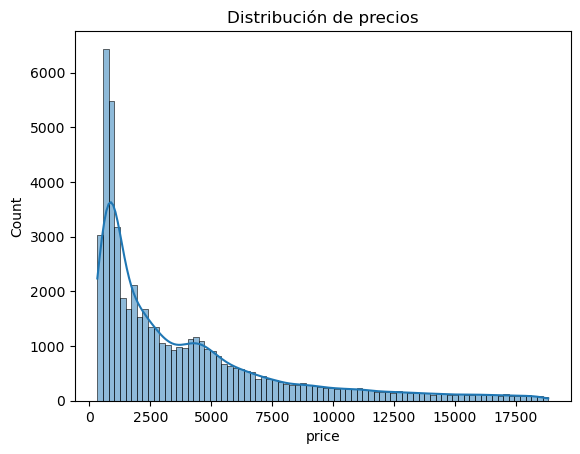

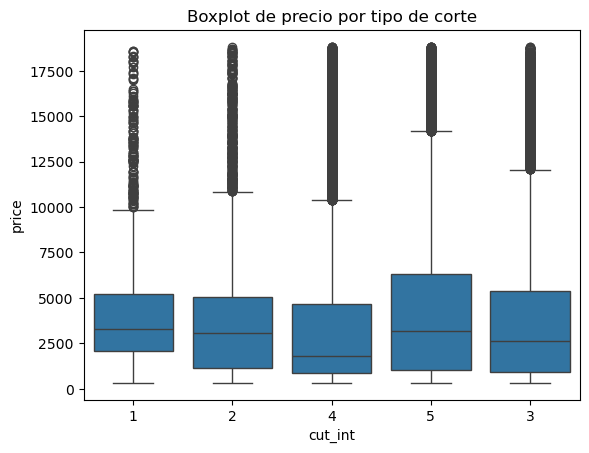

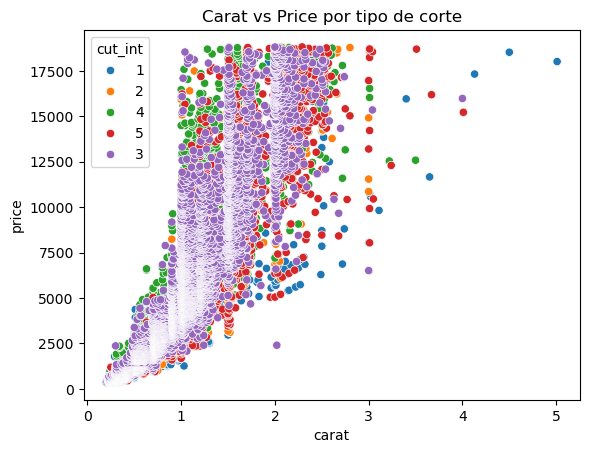

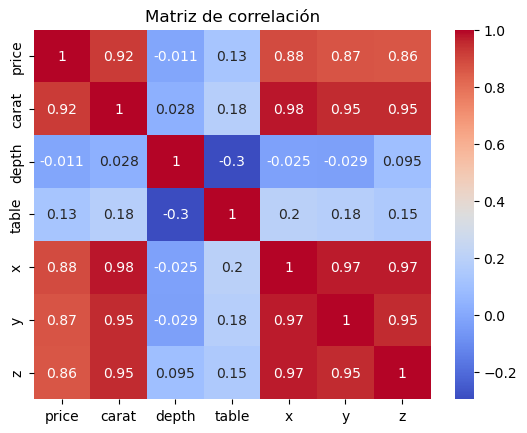

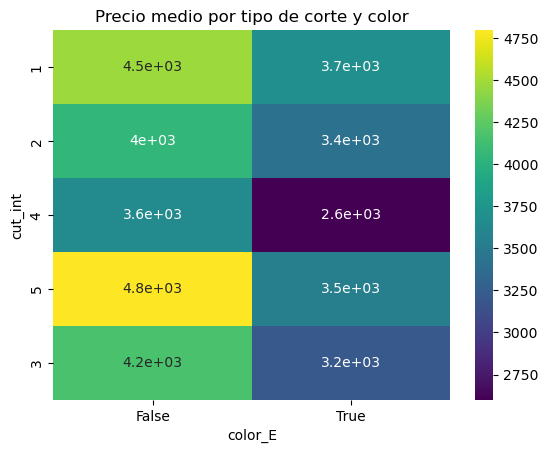

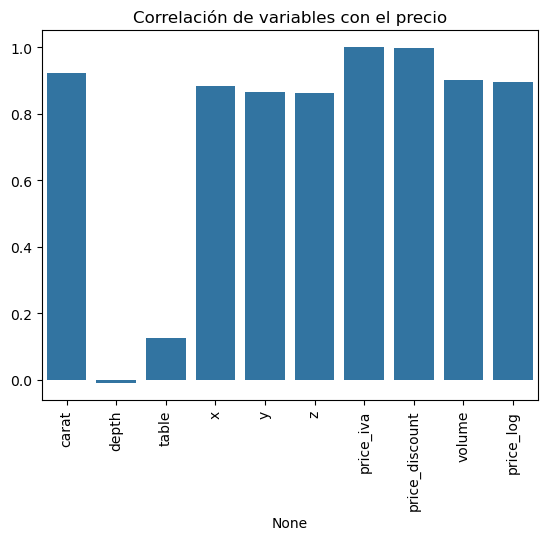

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Parte 1: Carga y limpieza de datos

# Leer el archivo CSV
df = pd.read_csv('diamonds.csv')

# Reemplazar valores '?' por valores nulos
df.replace('?', pd.NA, inplace=True)

# Convertir columnas a sus tipos adecuados
df['carat'] = df['carat'].astype('float32')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['cut'] = df['cut'].astype('category')
df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df['z'] = pd.to_numeric(df['z'], errors='coerce')

# Manejo de valores nulos
df['price'] = df['price'].fillna(df['price'].median())
df['x'] = df['x'].fillna(df['x'].mean())
df['y'] = df['y'].fillna(df['y'].mean())
df['z'] = df['z'].fillna(df['z'].mean())
df['cut'] = df['cut'].fillna(df['cut'].mode()[0])

# Crear columna cut_int con encoding ordinal (ahora usando directamente los valores de 'cut')
cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Ideal': 4, 'Premium': 5}
df['cut_int'] = df['cut'].map(cut_map)

# Encoding one-hot para otras columnas categóricas
df = pd.get_dummies(df, columns=['color', 'clarity'], drop_first=True)

# Parte 2: Transformaciones

# Crear columna 'price_iva'
df['price_iva'] = df['price'] * 1.21

# Crear columna 'price_discount'
def apply_discount(row):
    if row['price'] < 1000 and row['cut'] == 'Ideal':  # Ideal
        return row['price'] * 0.9
    elif 1000 <= row['price'] <= 5000 and row['cut'] == 'Premium':  # Premium
        return row['price'] * 0.85
    return row['price']

df['price_discount'] = df.apply(apply_discount, axis=1)

# Crear columna 'volume'
df['volume'] = df['x'] * df['y'] * df['z']

# Ordenar por 'cut' y 'price'
df.sort_values(by=['cut_int', 'price'], ascending=[True, True], inplace=True)

# Agrupaciones con observed=True
grouped = df.groupby('cut_int', observed=True).agg(
    price_mean=('price', 'mean'),
    price_max=('price', 'max'),
    price_min=('price', 'min'),
    carat_mean=('carat', 'mean'),
    carat_max=('carat', 'max'),
    carat_min=('carat', 'min')
).reset_index()
print(grouped)

# Parte 3: Distribuciones y transformaciones adicionales

# Visualización de outliers para 'price'
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df_filtered = df[(df['price'] >= lower_limit) & (df['price'] <= upper_limit)]

# Asimetría y curtosis
print(f"Asimetría de price: {df['price'].skew()}")
print(f"Curtosis de price: {df['price'].kurt()}")

# Transformar la columna 'price' con logaritmo
df['price_log'] = np.log(df['price'])

# Discretizar la columna 'price'
price_bins = [0, 1000, 5000, float('inf')]
price_labels = ['Barato', 'Medio', 'Caro']
df['price_category'] = pd.cut(df['price'], bins=price_bins, labels=price_labels)

# Parte 4: Visualizaciones

# Histograma y KDE para 'price'
sns.histplot(df['price'], kde=True)
plt.title('Distribución de precios')
plt.show()

# Boxplot para 'price' por tipo de corte
sns.boxplot(x='cut_int', y='price', data=df)
plt.title('Boxplot de precio por tipo de corte')
plt.show()

# Scatterplot para 'carat' vs 'price'
sns.scatterplot(x='carat', y='price', hue='cut_int', data=df)
plt.title('Carat vs Price por tipo de corte')
plt.show()

# Scatterplot interactivo con Plotly para Carat vs Price
fig = px.scatter(df, x='carat', y='price', color='cut', title="Carat vs Price por tipo de corte")
fig.show()

# Heatmap de correlaciones
correlation = df[['price', 'carat', 'depth', 'table', 'x', 'y', 'z']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

# Pivot table y heatmap
pivot_table = df.pivot_table(
    values='price', 
    index='cut_int', 
    columns='color_E', 
    aggfunc='mean', 
    observed=True
)
sns.heatmap(pivot_table, annot=True, cmap='viridis')
plt.title('Precio medio por tipo de corte y color')
plt.show()

# Filtrar solo columnas numéricas para calcular la correlación
numeric_df = df.select_dtypes(include=[np.number])

# Matriz de correlación
correlation_price = numeric_df.corr()['price'].drop('price')

# Gráfico de barras de correlación con precio
sns.barplot(x=correlation_price.index, y=correlation_price.values)
plt.title('Correlación de variables con el precio')
plt.xticks(rotation=90)
plt.show()

## 2: Transformaciones

In [29]:
# Intentar convertir la columna 'price' a numérico
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Verifica si hay valores nulos después de la conversión
print(df['price'].isnull().sum())
# Rellenar NaN con la mediana de la columna 'price'
df['price'] = df['price'].fillna(df['price'].median())
# Verifica las primeras filas de 'price' para detectar posibles problemas
print(df['price'].head())



0
8        337.0
28270    361.0
31611    369.0
31615    371.0
10030    416.0
Name: price, dtype: float64


## 3: Distribuciones

In [ ]:
# Visualización de outliers (columna price)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Filtro de outliers
filtro_outliers = (df['price'] >= lower_limit) & (df['price'] <= upper_limit)
df_no_outliers = df[filtro_outliers]

# Asimetría, curtosis y transformación logarítmica
df['price_log'] = np.log(df['price'] + 1)  # Evita problemas con valores 0 o negativos

# Histograma y boxplot por tipo de corte
px.histogram(df, x='price_log', color='cut')
px.box(df, x='cut', y='price_log')

# Discretización de precios
bins = [0, 1000, 5000, df['price'].max()]
labels = ['Barato', 'Medio', 'Caro']
df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels)

## 4: Visualizaciones

In [ ]:
# Univariantes: Histogramas y curvas de densidad
sns.histplot(df['carat'], kde=True)
sns.kdeplot(df['price'], shade=True)

# Boxplot
sns.boxplot(x='cut', y='price', data=df)

# Countplot
sns.countplot(x='cut', data=df)

# Bivariantes y multivariantes: Scatterplot
sns.scatterplot(x='carat', y='price', hue='cut', style='color', size='depth', data=df)

# Correlación con Pandas y visualización con Seaborn
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')

# Gráfico de barras para la columna 'price'
correlation_price = correlation['price'].sort_values(ascending=False)
correlation_price.plot(kind='bar')

# Pivot table y heatmap
pivot = df.pivot_table(index='cut', columns='color', values='price', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='viridis')

# Gráficas combinadas usando relplot
sns.relplot(x='carat', y='price', hue='cut', col='color', kind='scatter', data=df)


## Visualización de gráficos con Plotly

In [ ]:
# Histograma con Plotly
px.histogram(df, x='price', color='cut', nbins=50)

# Gráfico de dispersión 3D
px.scatter_3d(df, x='carat', y='price', z='depth', color='cut')

# Gráfico de líneas para precios agrupados por fecha simulada
df['date'] = pd.date_range(start='2023-01-01', periods=len(df))
df_sales = df.groupby('date', as_index=False)['price'].sum()
px.line(df_sales, x='date', y='price')
